In [2]:
import jax, torch
import jax.numpy as jnp
from geophyai.rnn import RNN
from geophyai.equations import Acoustic
from geophyai.signal import ricker
import numpy as np
import matplotlib.pyplot as plt

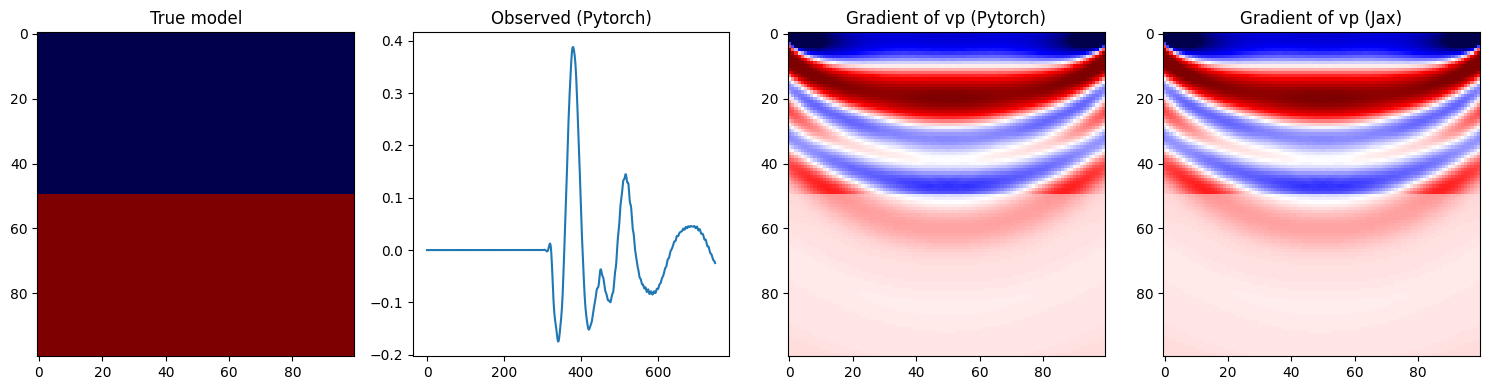

In [9]:
# Model parameters
nt = 1500
dt = 0.002
dh = 10
delay = 0.1
fm = 5
spatial_order = 8
shape = (100,100)

# Device
dev = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Create a 2-layer velocity model
true_model = np.ones(shape, dtype=np.float32)*1500
true_model[50:, :] = 2000

eq_kwargs = dict(spatial_order=spatial_order, device=dev)
solver_kwargs = dict(shape=shape, dev=dev, dh=dh, dt=dt, source_type=['h1'], receiver_type=['h1'], abcn=50, free_surface=False)
# Create a solver_torch
solver_torch = RNN(Acoustic(**eq_kwargs, backend='torch'), **solver_kwargs)
solver_jax = RNN(Acoustic(**eq_kwargs, backend='jax'), **solver_kwargs)

# Set the solver_torch parameters (Pytorch)
solver_torch.set_parameters([torch.from_numpy(true_model).to(dev)])
# Set the solver_jax parameters (Jax)
solver_jax.set_parameters([jnp.array(true_model)])
# Create a wavelet
t = np.arange(0, int(nt//2)*dt, dt)
wave = ricker(t-delay, f=fm)

# Acquicition geometry
sources = np.array([[1, 1]]) # in grid, shape=(nshots, 2)
receivers = np.array([[[99, 1]]]) # in grid, shape=(nshots, nreceivers, 2)

# Forward modeling
# Backward propagation (Pytorch)
obs_torch = solver_torch(wave, sources, receivers)
obs_torch.pow(2).sum().backward()
grad_torch = solver_torch.vp.grad.detach().cpu().numpy()  # Pytorch
# Backward propagation (Jax)
def fwi(vp):
    return (solver_jax(wave, sources, receivers, models=[vp])**2).sum()
grad_jax = jax.grad(fwi)(solver_jax.vp)

# Show the results
fig, axes=plt.subplots(1,4, figsize=(15,4))

axes[0].imshow(true_model, cmap='seismic', aspect='auto')
axes[0].set_title('True model')

axes[1].plot(obs_torch.detach().cpu().numpy().squeeze(), label='Observed data')
vmin,vmax=np.percentile(grad_torch, [1,99])
axes[1].set_title('Observed (Pytorch)')
axes[2].imshow(grad_torch, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
axes[2].set_title('Gradient of vp (Pytorch)')

axes[3].imshow(grad_jax, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
axes[3].set_title('Gradient of vp (Jax)')
fig.tight_layout()
plt.show()